The essence of Machine Learning is the "Function Fitting" problem.

You have a set of observed data - pairs of values (x, y). There is some relationship between x and y, and our goal is to find a function f such that f(x) is approximately y, for every pair (x, y), including pairs we have never seen before.

This is exactly why Machine Learning differs from traditional programming: in traditional programming, you write the function f yourself, while in machine learning, you let the computer discover the function f based on data.

## 1. Create a target function - ground truth
To know whether a model is working well, we need a set of correct answers to evaluate against. To keep things simple, we will define a formula ourselves and check whether the model can rediscover that same formula. We will use a quadratic function: f(x) = ax^2 + bx + c

In [ ]:
from functools import partial
import torch, matplotlib.pyplot as plt

# quadratic function - computes the value of y at a given x
def quad(a, b, c, x):
    return a*x**2 + b*x + c

# "bundles" a fixed set of parameters (a,b,c), returning a new function that only takes x
# -> each different (a,b,c) set produces a different function/curve
def mk_quad(a, b, c):
    return partial(quad, a, b, c)

The `mk_quad` function is like a model factory: each different set of parameters gives us a different model. In other words, a model is not a fixed piece of code, but a family of functions determined by its parameters.

## 2. Random noise - modeling the uncertainty of real data
If the generated data matched the original quadratic formula perfectly, the problem would not reflect reality, since in real life every measurement has some error. So we deliberately add random noise to the fake data (y) to mimic the "imperfect" nature of real data, before feeding it into the training process in the next steps.

In [ ]:
# generates random noise (following a normal distribution), with the same shape as x,
# with magnitude controlled by the scale parameter
def noise(x, scale):
    return torch.randn_like(x) * scale

# applies noise to the original data x:
# - mult: multiplicative noise coefficient (error scales with the magnitude of x)
# - add: additive noise coefficient (fixed error, independent of the magnitude of x)
def add_noise(x, mult, add):
    return x * (1 + noise(x, mult)) + noise(x, add)

In [ ]:
# fix the seed so that every notebook re-run produces the same fake dataset
torch.manual_seed(42)

# x: 20 points evenly spaced from -2 to 2 (input data)
x = torch.linspace(-2, 2, steps=20)[:, None] 

# y: "true" values following the formula a=3, b=2, c=1, with noise applied
# -> this is our observed data, simulating a real-world measurement
y = add_noise(quad(3, 2, 1, x), mult=0.15, add=1.5)

# plot the observed data (x,y) as a scatter plot
plt.scatter(x, y);

## 3. Fitting by eye
- Before automating the search for the right parameters with machine learning, let's try to find them manually first.

In [5]:
from ipywidgets import interact

@interact(a=1.5, b=1.5, c=1.5)
def plot_quad(a, b, c):
    plt.scatter(x, y)
    plt.plot(x, mk_quad(a, b, c)(x), color='red')

interactive(children=(FloatSlider(value=1.5, description='a', max=4.5, min=-1.5), FloatSlider(value=1.5, descr…

Through this adjustment process, we can see which parameters need to increase or decrease to make the function's output more accurate.

## 4. Loss function
In the example above, we only adjusted 3 parameters, but real neural networks have up to millions of parameters, so manually adjusting parameters is not feasible. To let the computer automatically compute and adjust the parameters optimally, we need to quantify how wrong/how well matched the results are as a single number. That is the role of the Loss function.

A loss function is a mathematical formula used to measure how far off a model's predictions are from the actual values. Depending on the task, different algorithms can be used, for example:
- For Regression:
    - Mean Square Error - MSE measures the squared distance between predictions and actual values. It penalizes large errors and outliers very heavily.
    - Mean Absolute Error - MAE: computes the absolute difference, without squaring. It measures every error fairly and is less affected by outliers.
- For Classification:
    - Cross-Entropy Loss (or Log Loss): measures the distance between the predicted probability distribution and the true label. This function heavily penalizes predictions that are wrong but highly confident, forcing the model to produce accurate probabilities.

Let's first look at MSE:

In [ ]:
# preds = predictions, acts = actual values
def mse(preds, acts):
    return ((preds - acts)**2).mean()

A closer look at the Mean Squared Error formula:
- `preds - acts`: the error at each point, which can be negative (prediction lower than actual) or positive.
- `**2`: squaring, for two important mathematical reasons:
    - It removes the sign (otherwise, positive and negative errors could cancel each other out when summed, giving a false impression of "low loss" even though the model is actually wrong in both directions).
    - It creates a nonlinear penalty: an error of 10 is penalized 100 times more than an error of 1 (not just 10 times), which makes the optimizer prioritize fixing large errors first, instead of letting the model "tolerate" a few very large errors as long as the overall result looks fine.
- `.mean()`: computes the average, combining the errors across the whole dataset into a single representative number. This is the step that turns "20 individual measurements" into "a single value to optimize".

### 4.1. Loss vs Metric
- A loss function must be differentiable, because the optimizer needs its derivative to work.
- A metric (such as accuracy) is a number that is easy for humans to understand, but is not necessarily differentiable, so it cannot be used directly for optimization.
- MSE here plays the role of the loss.

## 5. Derivatives and Gradients
The derivative of a function at a point is the instantaneous rate of change of that function at that point. Geometrically, it is the slope of the tangent line at that point.

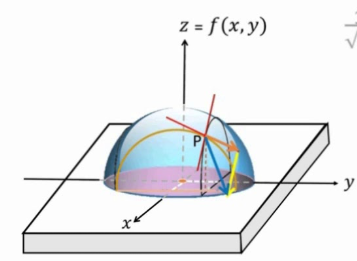

Gradient is the extension of the derivative concept to functions of multiple variables (here, a, b, c): it is a vector containing the partial derivative with respect to each variable:

gradient = (dloss/da, dloss/db, dloss/dc)

Each component answers: "if only this variable changes by a tiny amount, how much does the loss change?"

The gradient always points in the direction where the function increases fastest at that point, so the opposite direction is where it decreases fastest. Since our goal is to decrease the loss, we move in the opposite direction, which is called Gradient Descent.

To compute derivatives quickly, we can use PyTorch's `requires_grad_()` function.

In [ ]:
# The parameter set (a, b, c) we want to optimize so that quad(a,b,c,x) fits the data (x,y)
# The initial values (1.1, 1.1, 1.1) are arbitrary, since this is just the starting point,
# which will be updated step by step through gradient descent
params = torch.tensor([1.1, 1.1, 1.1])

# Turn on computation tracking (autograd) for params, so PyTorch can later
# automatically compute the gradient of the loss with respect to params
params.requires_grad_()

# quad_mse = Quadratic Mean Squared Error
# Loss function: build a model from the current params, then compute the MSE between its predictions and the real y
def quad_mse(params):
    f = mk_quad(*params)
    return mse(f(x), y)

# Compute the loss with the current params (just a number, no gradient yet)
loss = quad_mse(params)

# PyTorch automatically computes the derivative (backpropagation) of the loss
# with respect to each element of params, storing the result in params.grad
loss.backward()

## 6. Gradient Descent - updating parameters

As mentioned, to update the parameters we use gradient descent following the formula:

`new parameter = old parameter - learning rate x gradient of the loss`


In [ ]:
# learning rate: how fast we update params in the direction of the gradient
lr = 0.01

# no_grad() temporarily disables autograd, since we only want to update params without tracking gradients
with torch.no_grad():
    # update params in the direction that decreases the loss (gradient descent)
    params -= params.grad * lr
    # after updating, reset the gradient to 0 to prepare for the next step
    params.grad.zero_()

The gradient only tells us the direction to move in, but not how far to go. That is why we need a learning rate, which decides how big a step to take.

With that, we have completed one round of parameter updates.

## 7. Optimization loop

Each parameter update only takes one very small step, so we need to repeat the
process (compute loss, compute gradient, update params) many times in a row.
Each time the model trains through the entire dataset once, that is called one epoch.

Here we train for 500 epochs. We can freely change this to 100, 1000, and so on,
if we want the loss to decrease further.

In [21]:
for i in range(500):
    loss = quad_mse(params)
    loss.backward()
    with torch.no_grad():
        params -= params.grad * lr
        params.grad.zero_()
    print(f"step {i}: loss={loss.item():.3f}, params={params.tolist()}")

step 0: loss=2.632, params=[3.0511739253997803, 1.7428659200668335, 1.147877812385559]
step 1: loss=2.632, params=[3.0511744022369385, 1.7428659200668335, 1.1478768587112427]
step 2: loss=2.632, params=[3.0511746406555176, 1.7428659200668335, 1.1478759050369263]
step 3: loss=2.632, params=[3.051175117492676, 1.7428659200668335, 1.1478749513626099]
step 4: loss=2.632, params=[3.051175594329834, 1.7428659200668335, 1.1478739976882935]
step 5: loss=2.632, params=[3.051175832748413, 1.7428659200668335, 1.147873044013977]
step 6: loss=2.632, params=[3.0511763095855713, 1.7428659200668335, 1.1478720903396606]
step 7: loss=2.632, params=[3.0511765480041504, 1.7428659200668335, 1.1478712558746338]
step 8: loss=2.632, params=[3.0511770248413086, 1.7428659200668335, 1.147870421409607]
step 9: loss=2.632, params=[3.0511772632598877, 1.7428659200668335, 1.14786958694458]
step 10: loss=2.632, params=[3.051177501678467, 1.7428659200668335, 1.1478687524795532]
step 11: loss=2.632, params=[3.051177740

In [ ]:
plt.scatter(x, y, label='real data')
plt.plot(x, mk_quad(3, 2, 1)(x), color='green', linestyle='--', label='original function (a=3,b=2,c=1)')
plt.plot(x, mk_quad(*params.tolist())(x), color='red', label='model after training')
plt.legend()

Note: increasing the number of epochs does not always make the model more accurate. Looking at the 500 step log above, the params actually get "stuck" from around step 319 onward, because of a float32 precision limit (the update becomes so small that adding it to the current value produces no change at all).

There is also a deeper reason related to feature scaling: x^2 ranges over [0, 4], x ranges over [-2, 2], while the coefficient of c is always multiplied by 1. These three "features" have very different scales, which makes the gradients of a, b, and c very different in magnitude too, so a learns quickly while b barely moves at all, since its gradient is much smaller than the learning rate being used.

This is exactly why, in practice, techniques such as feature scaling (normalizing data to a common scale) or smarter optimizers (like Adam) are used instead of plain SGD with a fixed learning rate as we did here.

## 8. Learning Rate

In the code above, the learning rate (lr) was fixed at a single value (e.g. 0.01),
chosen by us. But lr has a huge effect on training:

- lr too small -> each update step is too tiny -> the loss decreases very slowly
  (slow convergence), requiring many more epochs to reach a good result.
- lr too large -> the update step overshoots the "bottom of the bowl" of the loss,
  which can make the loss oscillate or blow up (divergence) instead of decreasing.
- a suitable lr -> the loss decreases quickly and steadily.

We can get a feel for this by training again with a few different lr values. In
practice, there are libraries that can help find a good lr automatically, but for
now we will just experiment by training with several different learning rates.

In [ ]:
def train_with_lr(lr, epochs=20):
    params = torch.tensor([1.1, 1.1, 1.1])
    params.requires_grad_()
    losses = []
    for i in range(epochs):
        loss = quad_mse(params)
        loss.backward()
        with torch.no_grad():
            params -= params.grad * lr
            params.grad.zero_()
        losses.append(loss.item())
    return losses, params

# try 3 different lr values
for lr in [0.0001, 0.01, 1.5]:
    losses, params = train_with_lr(lr)
    print(f"lr={lr}: final loss={losses[-1]:.3f}, final params={params.tolist()}")

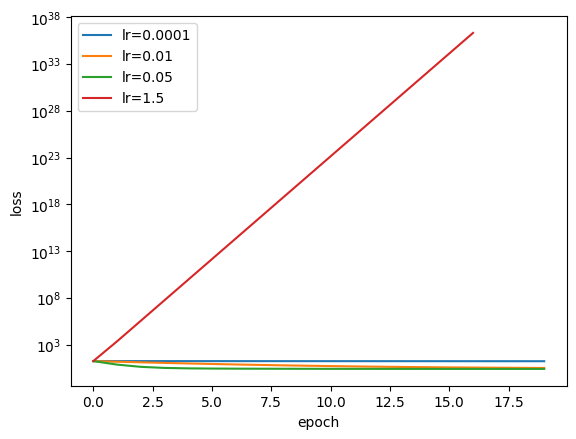

In [24]:
plt.figure()
for lr in [0.0001, 0.01, 0.05, 1.5]:
    losses, _ = train_with_lr(lr)
    plt.plot(losses, label=f'lr={lr}')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.yscale('log')

In [ ]:
lrs_to_test = [0.0001, 0.01, 1.5]
colors = ['blue', 'green', 'red']
results = {}
for lr in lrs_to_test:
    losses, final_params = train_with_lr(lr, epochs=20)
    results[lr] = (losses, final_params)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: same as before, shows all 3 lr values ---
for lr, color in zip(lrs_to_test, colors):
    losses, _ = results[lr]
    axes[0].plot(losses, color=color, label=f'lr={lr}')
axes[0].set_yscale('log')
axes[0].set_title('Loss comparison across epochs')
axes[0].legend()

# --- Chart 2: only plots lr=0.0001 and lr=0.01, leaving out lr=1.5 ---
axes[1].scatter(x, y, color='gray', alpha=0.5, label='observed data')
axes[1].plot(x, mk_quad(3, 2, 1)(x), color='black', linestyle='--', 
             linewidth=2, label='original function')

for lr, color in zip([0.0001, 0.01], ['blue', 'green']):  # leave out 1.5
    _, final_params = results[lr]
    axes[1].plot(x, mk_quad(*final_params.tolist())(x), color=color, 
                 label=f'model (lr={lr})')

axes[1].set_title('Learned models comparison (excluding divergent lr)')
axes[1].legend()
plt.tight_layout()
plt.show()